# Packages & Global Info

In [1]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Aggregation levels
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

In [3]:
# Boxplot setup
level_names = list(levels.keys())
x_positions = np.arange(1, len(level_names) + 1)
xtick_labels = ['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h']

boxstyle = dict(patch_artist=True,
                 boxprops=dict(facecolor='tab:blue', alpha=0.35, edgecolor='tab:blue'),
                 medianprops=dict(color='tab:blue', lw=1.5),
                 whiskerprops=dict(color='tab:blue'),
                 capprops=dict(color='tab:blue'))

# ARI

In [4]:
# ARI results
ARI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/ARI/ARI.csv", index_col=0)

ARI = {}
for col in ARI_df.columns:
    ARI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in ARI_df[col].items()
    }

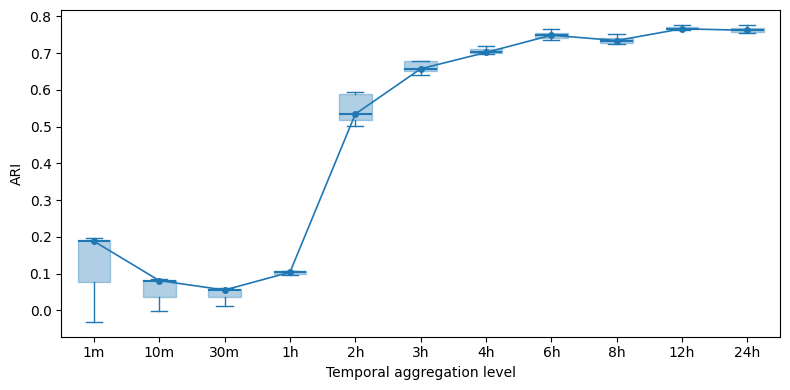

In [7]:
# Plot of ARIs as boxplots with median trend line
fig, ax = plt.subplots(figsize=(8, 4))

adj_rand = [np.array(list(ARI[name].values())) for name in level_names]

ax.boxplot(adj_rand, positions=x_positions, widths=0.5, showfliers=False, **boxstyle)

ari_medians = [np.median(a) for a in adj_rand]
ax.plot(x_positions, ari_medians, color='tab:blue', lw=1.2, marker='o', ms=4, zorder=3, label='Median')

ax.set_xticks(x_positions)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('Temporal aggregation level')
ax.set_ylabel('ARI')
plt.tight_layout()

# VI

In [8]:
# VI results 
VI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/VI/VI.csv", index_col=0)

VI = {}
for col in VI_df.columns:
    VI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in VI_df[col].items()
    }

inv_VI = {name: {pair: 1 - v for pair, v in d.items()} for name, d in VI.items()}

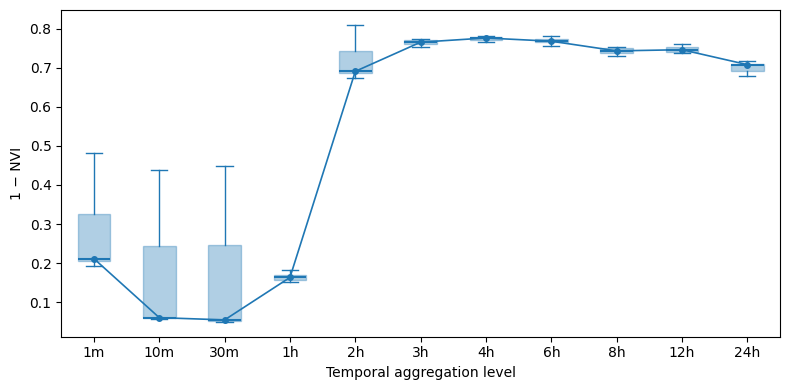

In [10]:
# Plot of (1 - NVI)s as boxplots with median trend line
fig, ax = plt.subplots(figsize=(8, 4))

inv_vi = [np.array(list(inv_VI[name].values())) for name in level_names]

ax.boxplot(inv_vi, positions=x_positions, widths=0.5, showfliers=False, **boxstyle)

inv_vi_medians = [np.median(s) for s in inv_vi]
ax.plot(x_positions, inv_vi_medians, color='tab:blue', lw=1.2, marker='o', ms=4, zorder=3, label='Median')

ax.set_xticks(x_positions)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('Temporal aggregation level')
ax.set_ylabel('1 − NVI')
plt.tight_layout()

# PSI

In [11]:
# ARI results
PSI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/03_code/PSI/PSI.csv", index_col=0)

PSI = {}
for col in PSI_df.columns:
    PSI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in PSI_df[col].items()
    }

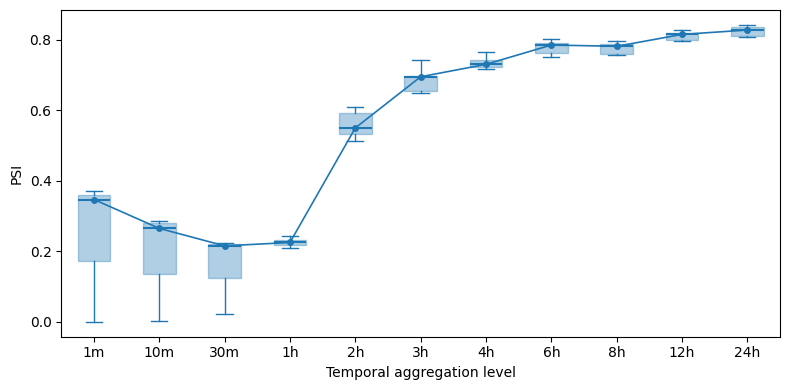

In [13]:
# Plot of PSIs as boxplots with median trend line
fig, ax = plt.subplots(figsize=(8, 4))

psi_vals = [np.array(list(PSI[name].values())) for name in level_names]

ax.boxplot(psi_vals, positions=x_positions, widths=0.5, showfliers=False, **boxstyle)

psi_medians = [np.median(p) for p in psi_vals]
ax.plot(x_positions, psi_medians, color='tab:blue', lw=1.2, marker='o', ms=4, zorder=3, label='Median')

ax.set_xticks(x_positions)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('Temporal aggregation level')
ax.set_ylabel('PSI')
plt.tight_layout()

## Combined

In [29]:
# Distribution of stability values for each measure 
ari_dist = np.concatenate([np.array(list(ARI[name].values())) for name in levels])
vi_dist  = np.concatenate([np.array(list(inv_VI[name].values())) for name in levels])
psi_dist = np.concatenate([np.array(list(PSI[name].values())) for name in levels])

In [30]:
# Median and interquartile range of measures
ari_median, ari_iqr = np.median(ari_dist), np.percentile(ari_dist, 75) - np.percentile(ari_dist, 25)
vi_median,  vi_iqr  = np.median(vi_dist), np.percentile(vi_dist, 75) - np.percentile(vi_dist, 25)
psi_median, psi_iqr = np.median(psi_dist), np.percentile(psi_dist, 75) - np.percentile(psi_dist, 25)

In [31]:
# Combined measure
combined_measure = {} 

for agg_level in levels:
    pairs = list(ARI[agg_level].keys())  
    z_ari = (np.array([ARI[agg_level][p] for p in pairs]) - ari_median) / ari_iqr
    z_vi  = (np.array([inv_VI[agg_level][p] for p in pairs]) - vi_median) / vi_iqr
    z_psi = (np.array([PSI[agg_level][p] for p in pairs]) - psi_median) / psi_iqr

    combined_measure[agg_level] = (z_ari + z_vi + z_psi) / 3

In [32]:
# Scaled combined measure and compute means
all_combined = np.concatenate([combined_measure[agg_level] for agg_level in levels])
c_min, c_max = all_combined.min(), all_combined.max()

combined_scaled = {
    agg_level: (combined_measure[agg_level] - c_min) / (c_max - c_min)
    for agg_level in levels
}

combined_medians = np.array([np.median(combined_scaled[agg_level]) for agg_level in levels])

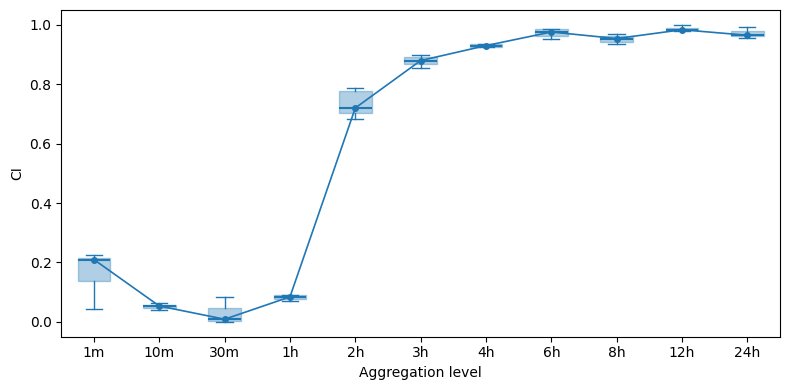

In [33]:
# Plot of combined measure as boxplots with median trend line, equally spaced x-axis
fig, ax = plt.subplots(figsize=(8, 4))

combined_vals = [combined_scaled[name] for name in level_names]

ax.boxplot(combined_vals, positions=x_positions, widths=0.5, showfliers=False, **boxstyle)

ax.plot(x_positions, combined_medians, color='tab:blue', lw=1.2, marker='o', ms=4, zorder=3, label='Median')

ax.set_xticks(x_positions)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('Aggregation level')
ax.set_ylabel('CI')
plt.tight_layout()

In [34]:
# # Save results to CSV
# import pandas as pd

# col_order = ['1 min','10 min','30 min','1 h','2 h','3 h','4 h','6 h','8 h','12 h','24 h']

# data = {
#     agg_level: dict(zip(ARI[agg_level].keys(), combined_scaled[agg_level]))
#     for agg_level in levels
# }

# dummy = pd.DataFrame(data)
# dummy.index = [f"{a}-{b}" for (a, b) in dummy.index]
# dummy.index.name = "Week pair"

# dummy = dummy[col_order]
# dummy.to_csv("drop_dest_comps_combined.csv")